In [4]:
import torch
import math
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from torch.optim import Adam

from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.normalization import BatchNorm
from nflows.transforms.autoregressive import MaskedPiecewiseRationalQuadraticAutoregressiveTransform

In [2]:
marginalised_ly = torch.load('charge_llr_v6_training_ly.pt')

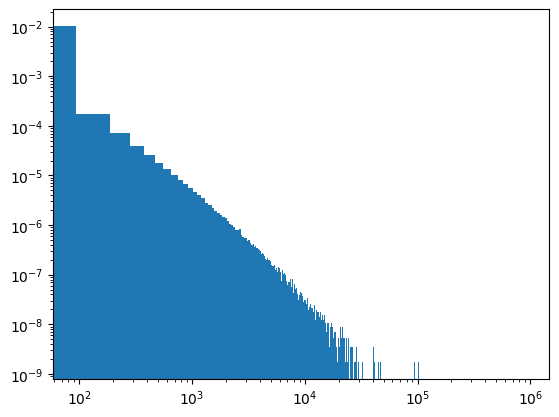

In [3]:
plt.hist(marginalised_ly[:,3].cpu().numpy(), bins=10000, density=True)
plt.yscale('log')
plt.xscale('log')

In [11]:
# --- data: mismatched (label=0) light yields trace out p_marginal(LY | point) ---
recorded = marginalised_ly
# mismatched_ly = recorded[recorded[:, 4] == 0][:, 3]
mismatched_ly = recorded[:, 3]
mismatched_ly = mismatched_ly[mismatched_ly > 0]  # avoid log(0) issues

# log10-space, since light yield spans many decades (same reasoning as the
# log_ly feature already used elsewhere in LLRnet)
log_ly = torch.log10(mismatched_ly).unsqueeze(1)  # (N, 1)

# standardize on top of the log transform -- helps the flow's base distribution
# (StandardNormal) match the data scale
log_ly_mean = log_ly.mean()
log_ly_std = log_ly.std()
x = (log_ly - log_ly_mean) / log_ly_std

# --- build a small RQS flow: a few autoregressive spline layers + batch norm ---
num_layers = 4
num_bins = 8

transforms = []
for _ in range(num_layers):
    transforms.append(
        MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
            features=1,
            hidden_features=32,
            num_bins=num_bins,
            tails='linear',
            tail_bound=5.0,
        )
    )
    transforms.append(BatchNorm(features=1))

transform = CompositeTransform(transforms)
base_dist = StandardNormal(shape=[1])
flow = Flow(transform, base_dist)

optimizer = Adam(flow.parameters(), lr=1e-3)

# --- train ---
epochs = 500
batch_size = 512
n = x.shape[0]

for epoch in range(epochs):
    perm = torch.randperm(n)
    total_loss = 0.0
    # for i in range(0, n, batch_size):
        # batch = x[perm[i:i + batch_size]]
    batch = x[perm[:batch_size]]
    optimizer.zero_grad()
    loss = -flow.log_prob(inputs=batch).mean()
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * batch.shape[0]
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, NLL: {total_loss / batch_size:.4f}")



Epoch 50/500, NLL: 0.8930
Epoch 100/500, NLL: 0.8497
Epoch 150/500, NLL: 1.7407
Epoch 200/500, NLL: 0.5567
Epoch 250/500, NLL: 1.3502
Epoch 300/500, NLL: 1.3674
Epoch 350/500, NLL: 1.1172
Epoch 400/500, NLL: 0.0387
Epoch 450/500, NLL: 1.0432
Epoch 500/500, NLL: 0.3739


In [15]:
x

tensor([[ 0.1176],
        [-0.5114],
        [-0.2189],
        ...,
        [-0.3467],
        [ 0.2325],
        [-0.5114]])

In [12]:
# --- evaluate the fitted marginal density p(log10(LY)) at new points ---
def marginal_log_ly_density(log_ly_values):
    """log_ly_values: torch.Tensor of shape (N,) or (N, 1), raw log10(LY)."""
    log_ly_values = log_ly_values.reshape(-1, 1)
    x_eval = (log_ly_values - log_ly_mean) / log_ly_std
    with torch.no_grad():
        log_prob_std = flow.log_prob(inputs=x_eval)
    # account for the standardization Jacobian: d(x)/d(log_ly) = 1/log_ly_std
    log_prob = log_prob_std - torch.log(log_ly_std)
    return torch.exp(log_prob)

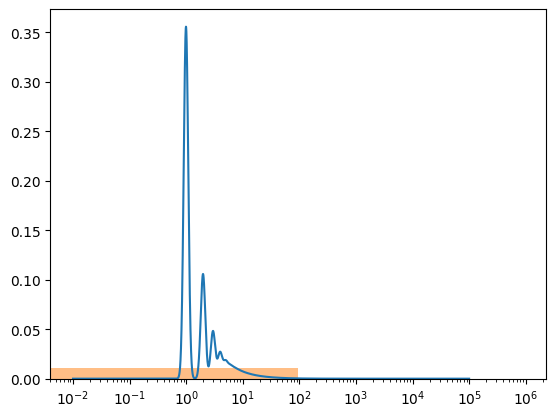

In [ ]:
test_set = torch.logspace(-2, 5, 10000)
test_probs = marginal_ly_density(test_set)
plt.plot(test_set, test_probs, label='Fitted Density')
plt.hist(mismatched_ly, bins=10000, density=True, alpha=0.5, label='Empirical Density')
plt.yscale('log')
plt.xscale('log')

In [ ]:
from scipy.stats import gaussian_kde

# --- data: mismatched (label=0) light yields trace out p_marginal(LY) ---
# recorded = llr_net.recorded_lys  # (N, 5): [x, y, z, light_yield, label]
# mismatched_ly = recorded[recorded[:, 4] == 0][:, 3].numpy()
recorded = marginalised_ly
# mismatched_ly = recorded[recorded[:, 4] == 0][:, 3]
mismatched_ly = recorded[:, 3].numpy()

zero_tol = 1e-6  # treat anything at/below this as "zero" (no signal)
is_zero = np.abs(mismatched_ly) <= zero_tol

p_zero = is_zero.mean()
positive_ly = mismatched_ly[~is_zero]
positive_ly = positive_ly[positive_ly > 0]

log_ly = np.log10(positive_ly)

n_bins = 50
counts, bin_edges = np.histogram(log_ly, bins=n_bins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def marginal_ly_density(ly_values):
    """
    Evaluate p(LY) for an array of light-yield values via linear interpolation
    over the log10(LY) histogram, weighted by (1 - p_zero) for the LY>0 piece.
    Returns 0 outside the histogram's observed range (no extrapolation).
    """
    ly_values = np.asarray(ly_values, dtype=np.float64)
    density = np.zeros_like(ly_values)

    positive_mask = ly_values > zero_tol
    log_ly_eval = np.log10(ly_values[positive_mask])

    # interpolate the log-space histogram density, 0 outside its range
    p_log = np.interp(log_ly_eval, bin_centers, counts, left=0.0, right=0.0)
    # convert density in log10(LY) space to density in LY space via the
    # Jacobian d(log10 c)/dc = 1/(c * ln(10))
    p_ly = p_log / (ly_values[positive_mask] * np.log(10.0))

    density[positive_mask] = (1.0 - p_zero) * p_ly
    return density

In [27]:
class HistogramMarginalDensity:
    """
    Marginal p(LY) fit once from recorded light yields, reusable for future
    evaluation. Handles a point mass at LY=0 plus a log10(LY) histogram for
    LY>0, skipping empty bins so interpolation only uses bins with support.
    """

    def __init__(self, light_yields, n_bins=50, zero_tol=1e-6):
        light_yields = np.asarray(light_yields, dtype=np.float64)
        is_zero = np.abs(light_yields) <= zero_tol

        self.zero_tol = zero_tol
        self.p_zero = is_zero.mean()

        positive_ly = light_yields[~is_zero]
        positive_ly = positive_ly[positive_ly > 0]
        log_ly = np.log10(positive_ly)

        counts, bin_edges = np.histogram(log_ly, bins=n_bins, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # keep only bins that actually contain data
        nonempty = counts > 0
        self.bin_centers = bin_centers[nonempty]
        self.counts = counts[nonempty]

    def __call__(self, ly_values):
        """
        Evaluate p(LY) at new light-yield values using the fitted histogram.
        Returns 0 outside the range spanned by non-empty bins.
        """
        ly_values = np.asarray(ly_values, dtype=np.float64)
        density = np.zeros_like(ly_values)

        positive_mask = ly_values > self.zero_tol
        log_ly_eval = np.log10(ly_values[positive_mask])

        p_log = np.interp(log_ly_eval, self.bin_centers, self.counts, left=0.0, right=0.0)
        p_ly = p_log / (ly_values[positive_mask] * np.log(10.0))

        density[positive_mask] = (1.0 - self.p_zero) * p_ly
        return density


# --- fit once ---
# recorded = llr_net.recorded_lys  # (N, 5): [x, y, z, light_yield, label]
# mismatched_ly = recorded[recorded[:, 4] == 0][:, 3].numpy()

marginal_ly_density = HistogramMarginalDensity(mismatched_ly, n_bins=10000)

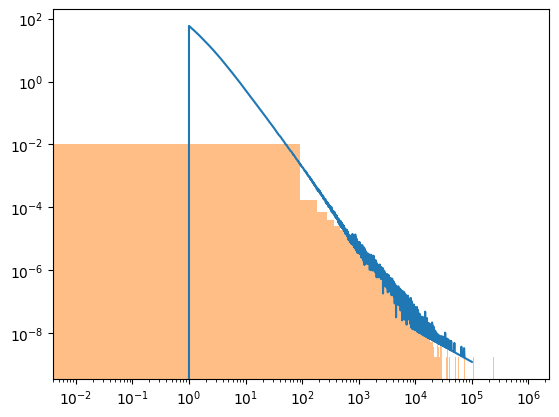

In [28]:
test_set = torch.logspace(-2, 5, 10000)
test_probs = marginal_ly_density(test_set)
plt.plot(test_set, test_probs, label='Fitted Density')
plt.hist(mismatched_ly, bins=10000, density=True, alpha=0.5, label='Empirical Density')
plt.yscale('log')
plt.xscale('log')